In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from train_functions import train_epochs
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused, show_cm

### start from benchmark model

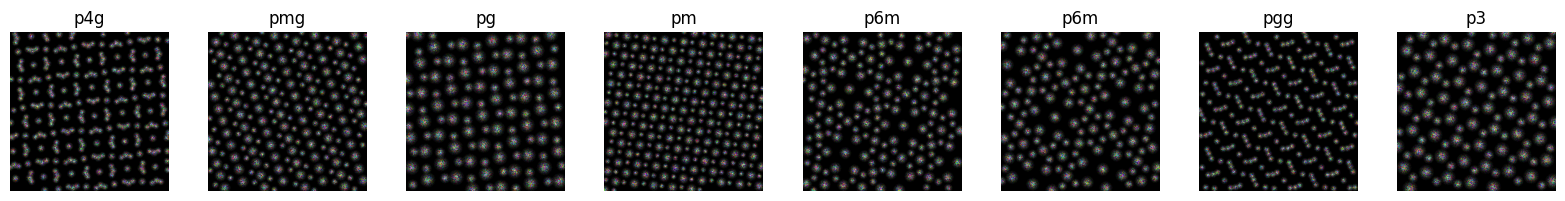

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

cv_atom_noised_ds = hdf5_dataset('../../../datasets/atom_noised_v4_rot_500K.h5', folder='test', transform=transforms.ToTensor())
cv_atom_noised_dl = DataLoader(cv_atom_noised_ds, batch_size=600, shuffle=False, num_workers=2)
viz_dataloader(cv_atom_noised_dl, label_converter=label_converter)

In [3]:
NAME = '01102024-benchmark-resnet50_from_scratch-v4_10m'

model = torch.load('../../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt')
device = torch.device('cuda:0')

printing set for seaborn


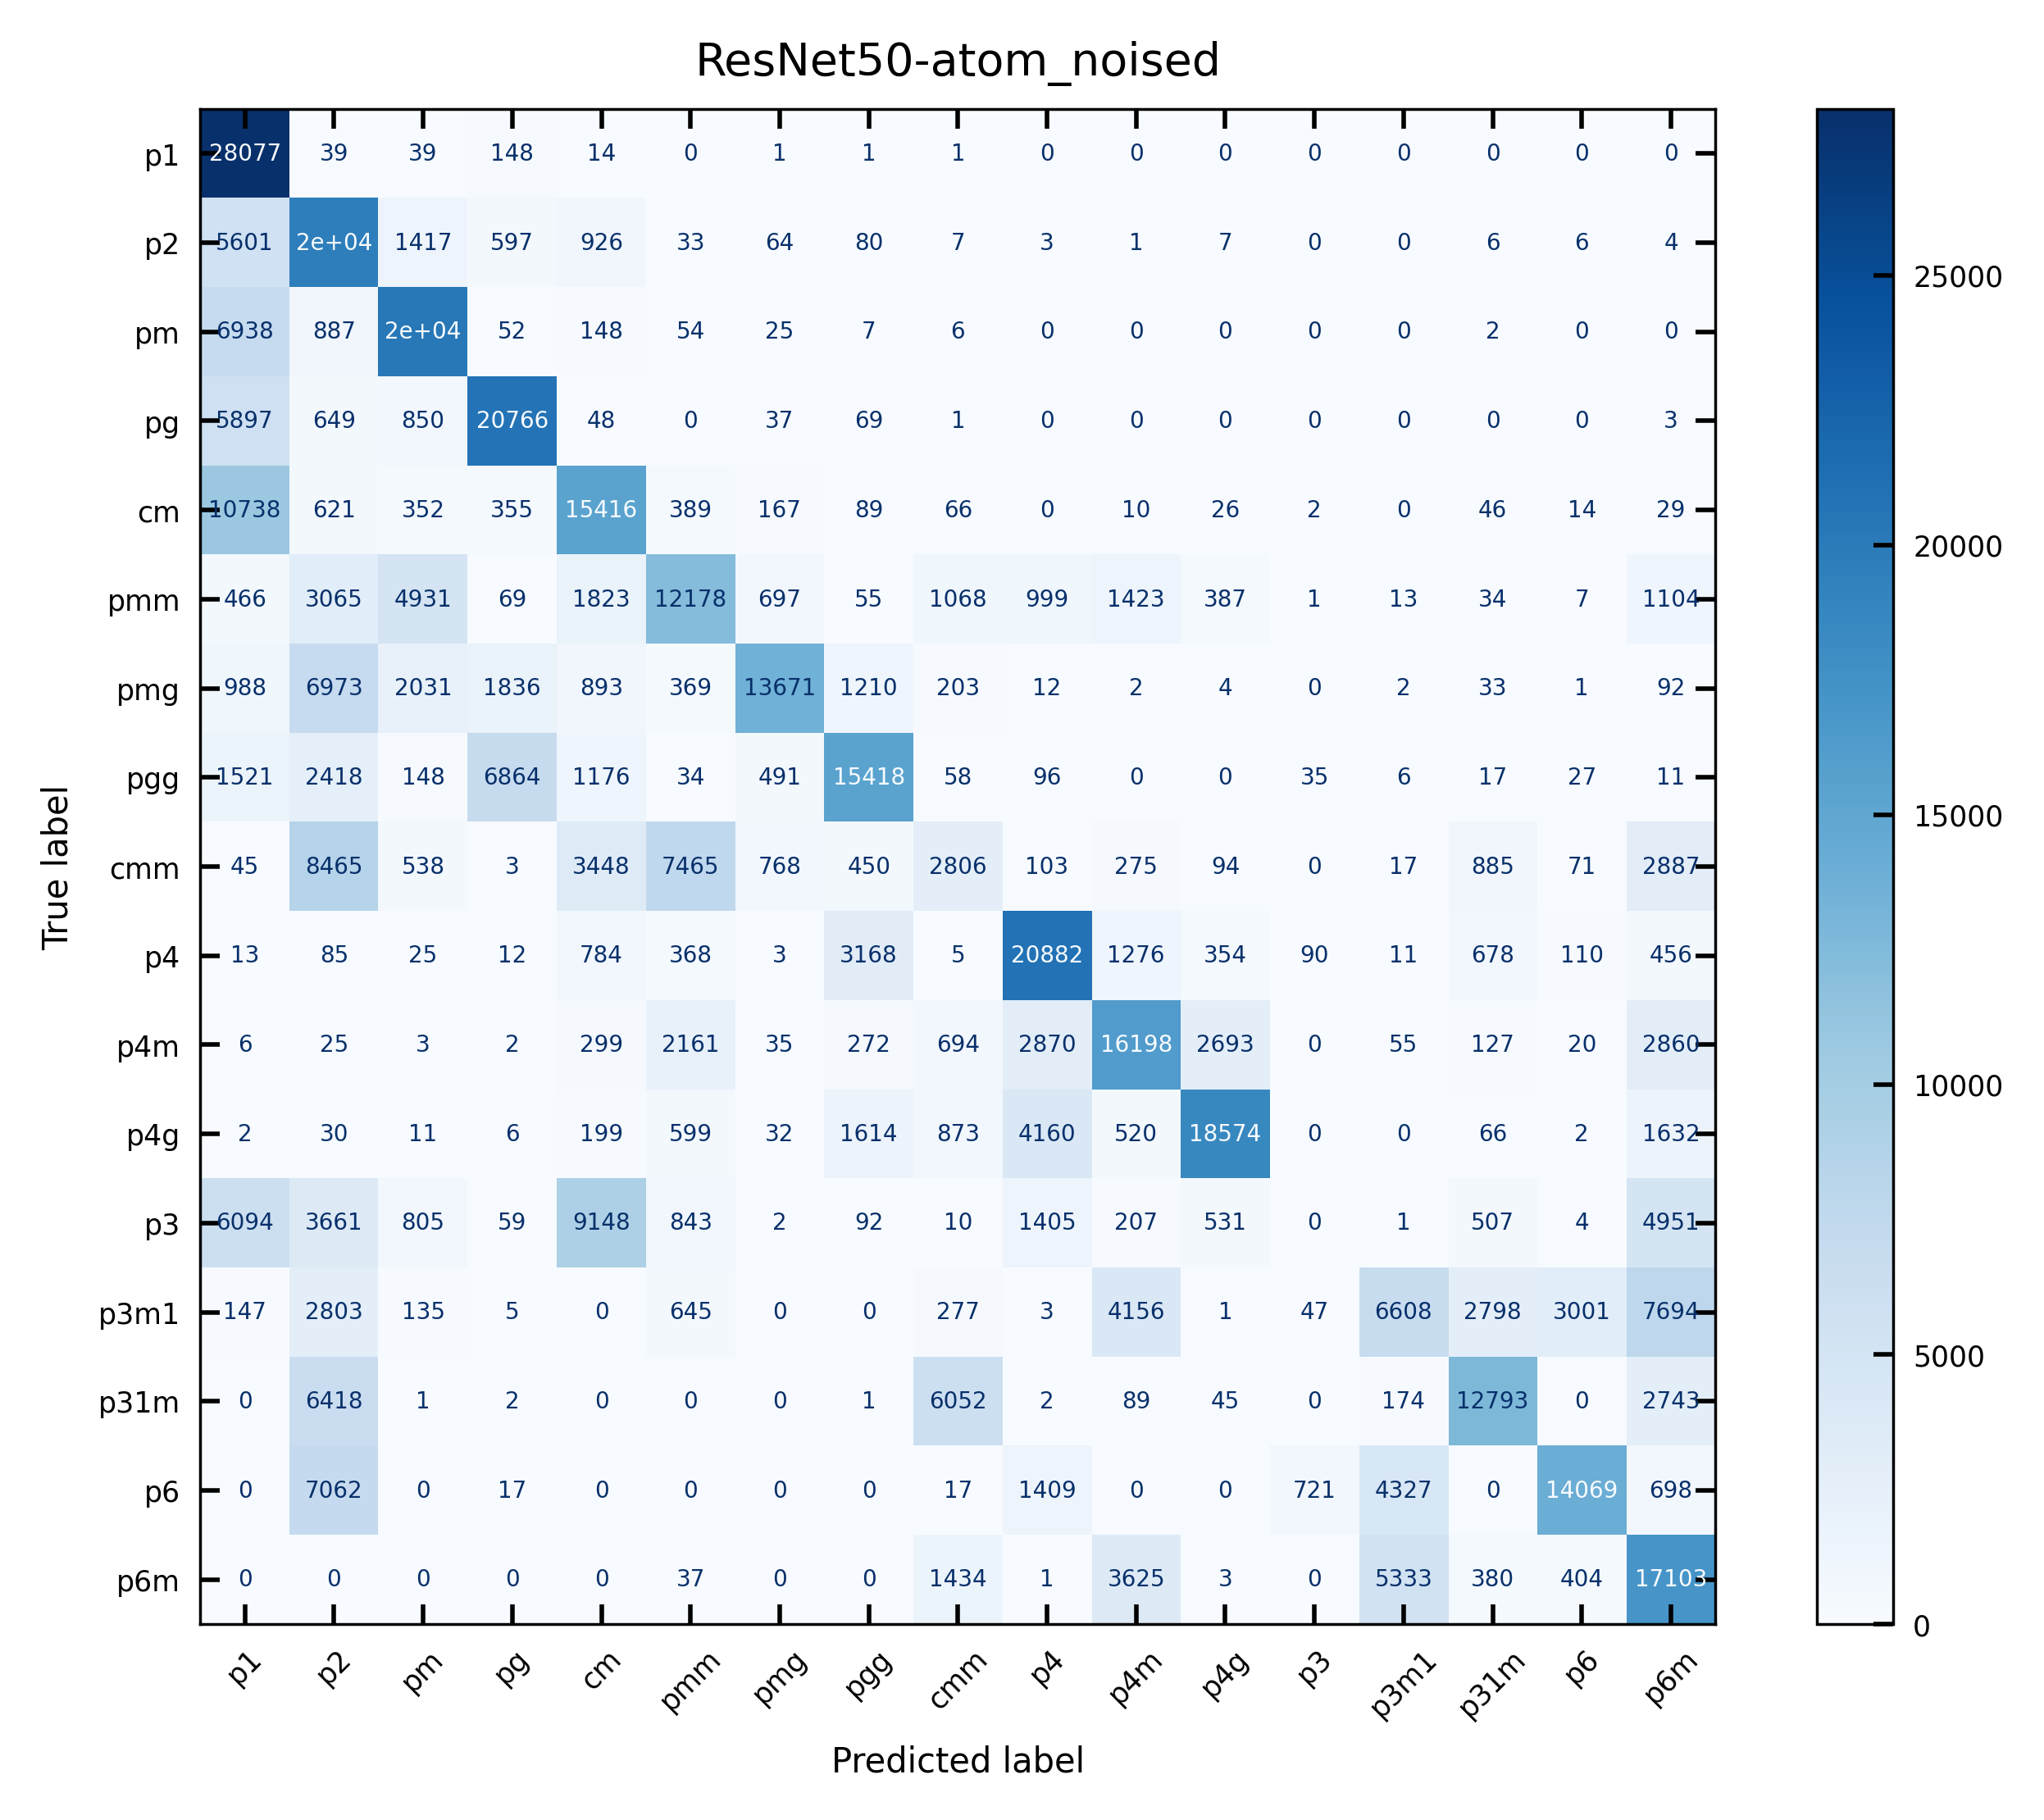

In [4]:
# cm = confusion_matrix(model, cv_atom_noised_dl, symmetry_classes, device, n_batches='all')
# np.save(f'../../../saved_results/Benchmark/ResNet50/{NAME}-cv_atom_noised_cm.npy', cm)

cm = np.load(f'../../../saved_results/Benchmark/ResNet50/{NAME}-cv_atom_noised_cm.npy')
plot_cm(cm, symmetry_classes, title='ResNet50-atom_noised', cm_style='simple', fig_style='printing', font_size=4)

### train the first layer only

In [4]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [7]:
model = torch.load('../../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt', map_location=torch.device('cpu'))
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

# freeze layers
for param in model.parameters():
    param.requires_grad = False

for param in model.conv1.parameters():
    param.requires_grad = True

model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5])
device = torch.device('cuda:0')

torch.Size([2, 17])


In [8]:
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_atom_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/20


  0%|          | 0/145 [00:00<?, ?it/s]

100%|██████████| 145/145 [03:22<00:00,  1.40s/it]


Training: Loss: 7.6591, Accuracy: 48.4099%, Time: 3.3819mins


100%|██████████| 17/17 [00:20<00:00,  1.18s/it]


...

Training: Loss: 6.5557, Accuracy: 54.5595%, Time: 2.8292mins


100%|██████████| 17/17 [00:16<00:00,  1.03it/s]


Validation : Loss : 6.4865, Accuracy: 55.2530%, Time: 0.28mins


100%|██████████| 136/136 [01:53<00:00,  1.19it/s]


Validation : Loss : 9.9660, Accuracy: 55.3649%, Time: 1.90mins


### unfreeze a few early layers

In [9]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [13]:
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
# Define separate parameter groups for different layers
optimizer = torch.optim.Adam([
    {'params': model.conv1.parameters(), 'lr': 1e-5},
    {'params': model.layer1.parameters(), 'lr': 1e-4},
    {'params': model.layer2.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-6}
], lr=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_atom_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/20


100%|██████████| 723/723 [10:13<00:00,  1.18it/s]


Training: Loss: 6.3684, Accuracy: 51.7789%, Time: 10.2217mins


100%|██████████| 81/81 [00:27<00:00,  2.95it/s]


Validation : Loss : 4.8356, Accuracy: 55.8429%, Time: 0.46mins


...

Training: Loss: 1.3367, Accuracy: 68.7641%, Time: 10.1616mins


100%|██████████| 81/81 [00:26<00:00,  3.03it/s]


Validation : Loss : 0.6595, Accuracy: 78.7118%, Time: 0.44mins


 59%|█████▊    | 1983/3388 [10:55<07:44,  3.03it/s]


KeyboardInterrupt: 

In [16]:
lr = 1e-3
start = 3
epochs = 17

loss_func = nn.CrossEntropyLoss()
# Define separate parameter groups for different layers
optimizer = torch.optim.Adam([
    {'params': model.conv1.parameters(), 'lr': 1e-5},
    {'params': model.layer1.parameters(), 'lr': 1e-4},
    {'params': model.layer2.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-6}
], lr=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_atom_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 4/20


100%|██████████| 723/723 [10:13<00:00,  1.18it/s]


Training: Loss: 0.8204, Accuracy: 75.2949%, Time: 10.2302mins


100%|██████████| 81/81 [00:27<00:00,  2.98it/s]


Validation : Loss : 0.5603, Accuracy: 81.6800%, Time: 0.45mins


...

Training: Loss: 0.0616, Accuracy: 98.0392%, Time: 10.1879mins


100%|██████████| 81/81 [00:27<00:00,  2.97it/s]


Validation : Loss : 0.0585, Accuracy: 98.0309%, Time: 0.45mins


100%|██████████| 678/678 [03:46<00:00,  3.00it/s]


Validation : Loss : 1.1310, Accuracy: 69.8805%, Time: 3.77mins


In [18]:
for param in model.parameters():
    param.requires_grad = False

for param in model.conv1.parameters():
    param.requires_grad = True

In [19]:
lr = 1e-3
start = 20
epochs = 10

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_atom_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 21/30


100%|██████████| 723/723 [08:37<00:00,  1.40it/s]


Training: Loss: 0.0612, Accuracy: 98.0448%, Time: 8.6300mins


100%|██████████| 81/81 [00:25<00:00,  3.12it/s]


Validation : Loss : 0.0584, Accuracy: 98.0371%, Time: 0.43mins


...

Training: Loss: 0.0608, Accuracy: 98.0618%, Time: 8.4213mins


100%|██████████| 81/81 [00:25<00:00,  3.16it/s]


Validation : Loss : 0.0585, Accuracy: 98.0247%, Time: 0.43mins


 44%|████▍     | 300/678 [01:33<01:57,  3.21it/s]


KeyboardInterrupt: 